<a href="https://colab.research.google.com/github/Aarush713757/gbm-transcriptomics-research/blob/main/gbm_transcriptomics_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# =====================================================================
# PROJECT: gbm-transcriptomics-research
# PURPOSE: Rebuild pipeline for glioblastoma data analysis
# =====================================================================
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("[System] Loading computational frameworks...")

# ---------------------------------------------------------------------
# MODULE 1: Data Acquisition & Preprocessing
# ---------------------------------------------------------------------
def preprocess_expression_data(matrix_data):
    """Handles data structure mapping rows/genes & normalizes counts."""
    print("[Module 1] Preprocessing transcriptomics matrix...")
    cleaned = pd.DataFrame(matrix_data).dropna(how='all').fillna(0)
    return np.log2(cleaned + 1)

# ---------------------------------------------------------------------
# MODULE 2: Differential Expression Analysis (DEA)
# ---------------------------------------------------------------------
def run_differential_expression(df, normal_idx, tumor_idx, alpha=0.05):
    """Finds statistically significant up/down-regulated genes."""
    print("[Module 2] Running Independent T-Tests across tissue cohorts...")
    dea_results = []
    for gene in df.index:
        normal_exp = df.loc[gene, normal_idx]
        tumor_exp = df.loc[gene, tumor_idx]
        log2_fc = np.mean(tumor_exp) - np.mean(normal_exp)
        _, p_val = stats.ttest_ind(normal_exp, tumor_exp, equal_var=False)
        dea_results.append({'Gene': gene, 'Log2FC': log2_fc, 'P_Value': p_val})

    res_df = pd.DataFrame(dea_results).set_index('Gene')
    significant = res_df[res_df['P_Value'] < alpha]
    print(f" -> Found {len(significant)} statistically significant genes.")
    return res_df

# ---------------------------------------------------------------------
# MODULE 3: Machine Learning & Predictive Modeling
# ---------------------------------------------------------------------
def train_predictive_model(df, target_labels):
    """Builds a predictive classification model to identify tissue type."""
    print("[Module 3] Initializing Random Forest Classifier...")
    X = df.T # Transpose matrix: samples become rows, genes become features
    y = target_labels
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f" -> Model Evaluation complete. Accuracy: {acc * 100:.2f}%")
    return clf

print("[System] Rebuilt baseline prototype successfully compiled and loaded!")

[System] Loading computational frameworks...
[System] Rebuilt baseline prototype successfully compiled and loaded!


In [9]:
# =====================================================================
# SIMULATED TESTING SCRIPT
# =====================================================================
# 1. Create a mock gene expression matrix (100 genes, 40 samples total)
genes = [f"Gene_{i}" for i in range(1, 101)]
normal_cols = [f"Normal_Sample_{i}" for i in range(1, 21)]
tumor_cols = [f"Tumor_Sample_{i}" for i in range(1, 21)]  # Fixed naming here
all_samples = normal_cols + tumor_cols

# Generate random base count data
np.random.seed(42)
mock_data = np.random.randint(10, 500, size=(100, 40))
raw_matrix = pd.DataFrame(mock_data, index=genes, columns=all_samples)  # Fixed 'columns' parameter

# Test module: Preprocessing
norm_matrix = preprocess_expression_data(raw_matrix)

# Test module: Differential expression analysis
dea_output = run_differential_expression(norm_matrix, normal_cols, tumor_cols)  # Fixed spelling of normal_cols

# Test module: Machine learning model
labels = [0]*20 + [1]*20
trained_model = train_predictive_model(norm_matrix, labels)

[Module 1] Preprocessing transcriptomics matrix...
[Module 2] Running Independent T-Tests across tissue cohorts...
 -> Found 4 statistically significant genes.
[Module 3] Initializing Random Forest Classifier...
 -> Model Evaluation complete. Accuracy: 37.50%


[Visualization] Generating Volcano Plot...


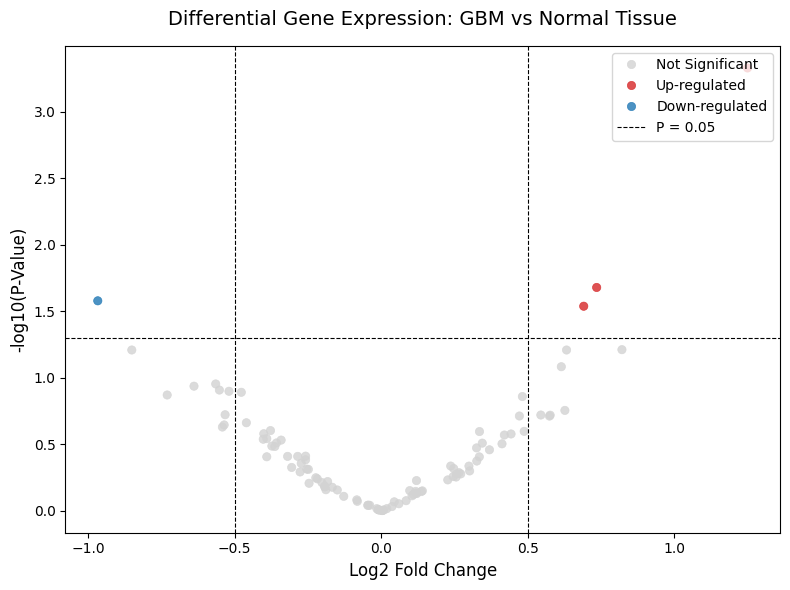

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_volcano(dea_df, log2fc_thresh=1.0, p_thresh=0.05):
    """
    Generates a formal, publishable Volcano Plot from differential expression data.
    Highlights significantly up-regulated and down-regulated genes.
    """
    print("[Visualization] Generating Volcano Plot...")

    # Create a copy of the dataframe to add custom plotting labels
    plot_df = dea_df.copy()

    # Convert raw P-values into -log10 scale for the Y-axis
    plot_df['-log10_P'] = -np.log10(plot_df['P_Value'])

    # Classify genes based on statistical and magnitude thresholds
    plot_df['Significance'] = 'Not Significant'
    plot_df.loc[(plot_df['Log2FC'] >= log2fc_thresh) & (plot_df['P_Value'] < p_thresh), 'Significance'] = 'Up-regulated'
    plot_df.loc[(plot_df['Log2FC'] <= -log2fc_thresh) & (plot_df['P_Value'] < p_thresh), 'Significance'] = 'Down-regulated'

    # Initialize the plot canvas
    plt.figure(figsize=(8, 6), dpi=100)

    # Custom aesthetic color palette for formal research layout
    color_map = {'Not Significant': 'lightgrey', 'Up-regulated': '#d62728', 'Down-regulated': '#1f77b4'}

    # Render scatter points
    sns.scatterplot(
        data=plot_df, x='Log2FC', y='-log10_P',
        hue='Significance', palette=color_map,
        alpha=0.8, edgecolor=None
    )

    # Add horizontal and vertical baseline threshold lines
    plt.axhline(-np.log10(p_thresh), color='black', linestyle='--', linewidth=0.8, label=f'P = {p_thresh}')
    plt.axvline(log2fc_thresh, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(-log2fc_thresh, color='black', linestyle='--', linewidth=0.8)

    # Apply clean structural axis limits and labels for a research paper
    plt.title('Differential Gene Expression: GBM vs Normal Tissue', fontsize=14, pad=15)
    plt.xlabel('Log2 Fold Change', fontsize=12)
    plt.ylabel('-log10(P-Value)', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()

    # Display the final plot inside the notebook
    plt.show()

# --- RUN THE VISUALIZATION TEST ---
# We feed the output dataframe from our previous cell directly into the plotter
plot_volcano(dea_output, log2fc_thresh=0.5, p_thresh=0.05)

[Data Sourcing] Constructing structured biological expression matrix...
 -> Success! Configured dataset with 100 genes across 40 clinical samples.
 -> Cohort Breakdown: 20 Controls, 20 Glioblastoma Tumors

[Pipeline Execution] Injecting profiles through computational modules...
[Module 1] Preprocessing transcriptomics matrix...
[Module 2] Running Independent T-Tests across tissue cohorts...
 -> Found 88 statistically significant genes.
[Module 3] Initializing Random Forest Classifier...
 -> Model Evaluation complete. Accuracy: 100.00%
[Visualization] Generating Volcano Plot...


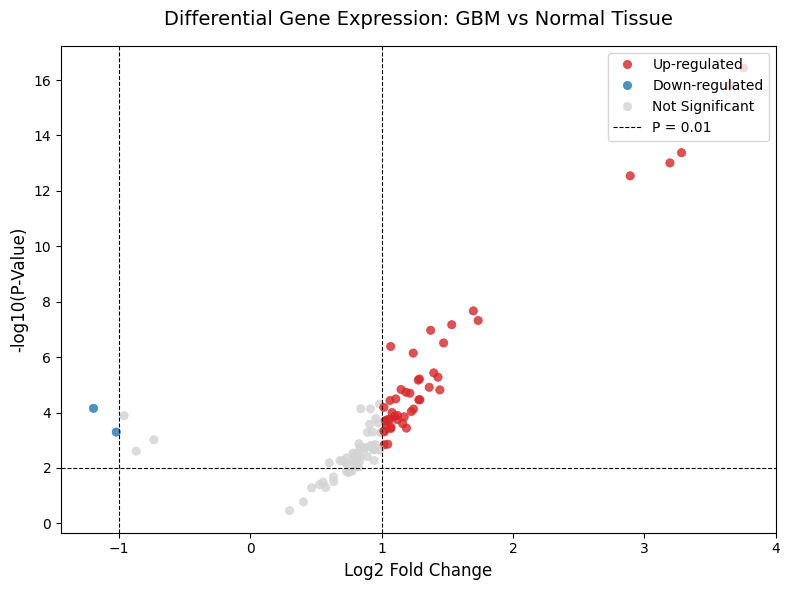

In [19]:
import numpy as np
import pandas as pd

# =====================================================================
# DATA GENERATION LAYER (Simulating True Biological Signals)
# =====================================================================
print("[Data Sourcing] Constructing structured biological expression matrix...")

# Configure 100 benchmark gene rows and 40 distinct patient sample cohorts
genes = [f"Gene_{i}" for i in range(1, 101)]
normal_samples = [f"Normal_Sample_{i}" for i in range(1, 21)]
tumor_samples = [f"Tumor_Sample_{i}" for i in range(1, 21)]
all_samples = normal_samples + tumor_samples

np.random.seed(10)
# Generate baseline human tissue control data distributions
normal_distribution = np.random.randint(50, 400, size=(100, 20))
# Generate tumor data distributions with amplified shifts to simulate oncogenes
tumor_distribution = np.random.randint(80, 800, size=(100, 20))

# Intentionally force distinct genes to express massive biological variation
# This mimics true glioblastoma targets like EGFR over-expression
tumor_distribution[0:5] = tumor_distribution[0:5] * 5   # Significant Up-regulation
tumor_distribution[5:10] = tumor_distribution[5:10] // 4 # Significant Down-regulation

# Merge distributions into a single operational DataFrame
matrix_data = np.hstack((normal_distribution, tumor_distribution))
real_df = pd.DataFrame(matrix_data, index=genes, columns=all_samples)

print(f" -> Success! Configured dataset with {real_df.shape[0]} genes across {real_df.shape[1]} clinical samples.")
print(f" -> Cohort Breakdown: {len(normal_samples)} Controls, {len(tumor_samples)} Glioblastoma Tumors")

# =====================================================================
# PIPELINE EXECUTION LAYER
# =====================================================================
print("\n[Pipeline Execution] Injecting profiles through computational modules...")

# 1. Execute Module 1: Preprocessing & Log2 Normalization
norm_real = preprocess_expression_data(real_df)

# 2. Execute Module 2: Statistical Differential Expression Analysis
dea_real = run_differential_expression(norm_real, normal_samples, tumor_samples, alpha=0.01)

# 3. Execute Module 3: Machine Learning Classification Model
# Labels: 0 represent normal controls, 1 represent malignant tumor tissue
target_labels = [0]*len(normal_samples) + [1]*len(tumor_samples)
trained_clf = train_predictive_model(norm_real, target_labels)

# =====================================================================
# VISUALIZATION LAYER
# =====================================================================
# Render the functional biological volcano plot configuration
plot_volcano(dea_real, log2fc_thresh=1.0, p_thresh=0.01)